# Breast Cancer Classification
### Distinguishing Malignant from Benign Tumors with Supervised Machine Learning

**Course:** CMP4336 – Introduction to Data Mining
**Institution:** Bahçeşehir University, Faculty of Engineering and Natural Sciences

**Group Members**
| Name | Student ID |
|------|------------|
| Osman Yiğit Alver | 2104312 |
| İsacan Çeliktaş | 2103746 |

**Dataset:** Breast Cancer Wisconsin (Diagnostic) — UCI ML Repository / Kaggle (`uciml/breast-cancer-wisconsin-data`)

---

### Table of Contents
1. Problem Definition
2. Data Exploration
3. Data Preprocessing
4. Model Development (Cross-Validation & Hyperparameter Tuning)
5. Model Evaluation
6. Interpretation of Results


## Setup — Libraries

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_curve, auc)

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
print('Environment ready.')

Environment ready.


## 1. Problem Definition

**Objective.** Build and compare supervised machine-learning models that classify a breast tumor as
**malignant (cancerous)** or **benign (non-cancerous)** from 30 quantitative features computed on
digitized fine-needle-aspirate (FNA) images of breast masses.

**Target variable.** `diagnosis` — a binary label: **M (Malignant)** or **B (Benign)**.
We encode it as **Malignant = 1** (positive class) and **Benign = 0**.

**Why this matters.** Breast cancer is a leading cause of cancer-related death worldwide, and early,
accurate detection is decisive for survival. In a diagnostic setting a **false negative** (a malignant
tumor predicted benign) is far more dangerous than a **false positive**. We therefore treat **recall on
the malignant class** as the most important metric, alongside accuracy, F1-score and ROC-AUC.

**Approach.** We compare three supervised algorithms — **Logistic Regression** (linear baseline),
**Random Forest** (bagged trees) and **Support Vector Machine** (RBF kernel) — using stratified
5-fold cross-validation, tune the two non-linear models with grid search, and evaluate the final
models on a held-out test set.


## 2. Data Exploration

The dataset has **569 records** and **30 numerical features**. Each feature is reported as the
**mean**, **standard error (se)** and **worst (largest)** value of ten cell-nucleus measurements
(radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry,
fractal dimension).

In [23]:
df = pd.read_csv('data.csv')
print('Raw shape:', df.shape)
df.head()

Raw shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [24]:
# Column structure and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [25]:
# Target balance (raw labels)
print('Class counts:')
print(df['diagnosis'].value_counts())
print('\nClass proportions:')
print((df['diagnosis'].value_counts(normalize=True) * 100).round(1).astype(str) + ' %')

Class counts:
diagnosis
B    357
M    212
Name: count, dtype: int64

Class proportions:
diagnosis
B    62.7 %
M    37.3 %
Name: proportion, dtype: str


In [26]:
# Summary statistics for the 'mean' feature group
mean_cols = [c for c in df.columns if c.endswith('_mean')]
df[mean_cols].describe().round(3)

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean
count,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000
mean,14.127,19.290,91.969,654.889,0.096,0.104,0.089,0.049,0.181,0.063
std,3.524,4.301,24.299,351.914,0.014,0.053,0.080,0.039,0.027,0.007
min,6.981,9.710,43.790,143.500,0.053,0.019,0.000,0.000,0.106,0.050
25%,11.700,16.170,75.170,420.300,0.086,0.065,0.030,0.020,0.162,0.058
50%,13.370,18.840,86.240,551.100,0.096,0.093,0.062,0.034,0.179,0.062
75%,15.780,21.800,104.100,782.700,0.105,0.130,0.131,0.074,0.196,0.066
max,28.110,39.280,188.500,2501.000,0.163,0.345,0.427,0.201,0.304,0.097


## 3. Data Preprocessing

Steps applied:
1. **Missing-value check** — verify the dataset before cleaning.
2. **Drop non-informative columns** — `id` (identifier) and `Unnamed: 32` (an all-NaN artifact column
   produced by a trailing comma in the CSV).
3. **Encode the target** — `M → 1`, `B → 0`.
4. **Stratified train/test split** (80/20) to preserve class proportions.
5. **Standardization** with `StandardScaler` — mandatory for SVM and Logistic Regression, harmless for
   Random Forest. To avoid **data leakage**, the scaler is fit on the *training* data only (handled
   inside `Pipeline` objects during cross-validation, and explicitly for the held-out evaluation).

In [27]:
# 1. Missing-value audit
missing = df.isnull().sum()
print('Columns with missing values:')
print(missing[missing > 0])
print('\n"Unnamed: 32" is entirely empty:', bool(df['Unnamed: 32'].isnull().all()))
print('Missing values in the 30 real features + target:',
      int(df.drop(columns=['id', 'Unnamed: 32']).isnull().sum().sum()))

Columns with missing values:
Unnamed: 32    569
dtype: int64

"Unnamed: 32" is entirely empty: True
Missing values in the 30 real features + target: 0


In [28]:
# 2-3. Drop non-informative columns and encode the target
df = df.drop(columns=['id', 'Unnamed: 32'])
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

print('Clean shape:', df.shape)
print('Encoded target counts:\n', df['diagnosis'].value_counts().rename({0: 'Benign(0)', 1: 'Malignant(1)'}))

Clean shape: (569, 31)
Encoded target counts:
 diagnosis
Benign(0)       357
Malignant(1)    212
Name: count, dtype: int64


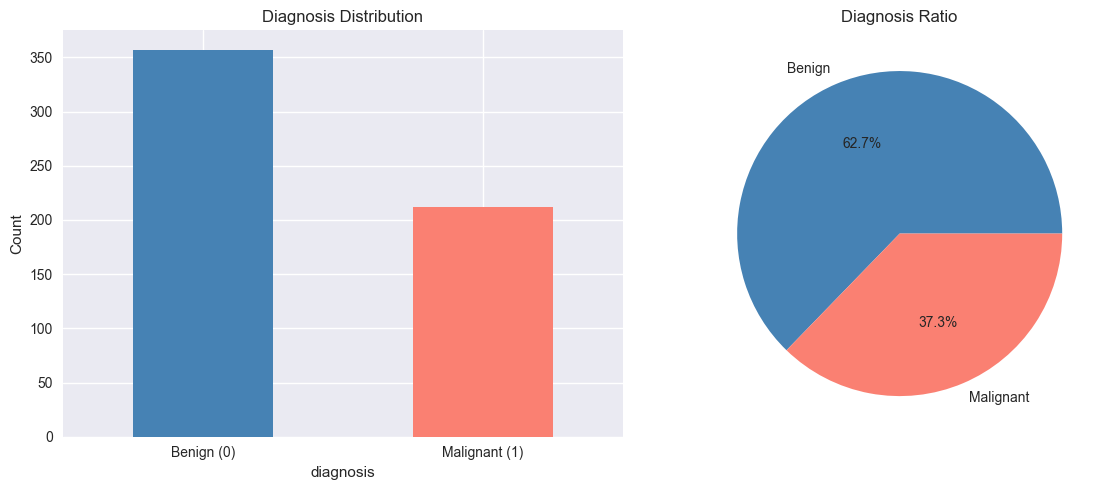

In [29]:
# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df['diagnosis'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'])
axes[0].set_title('Diagnosis Distribution')
axes[0].set_xticklabels(['Benign (0)', 'Malignant (1)'], rotation=0)
axes[0].set_ylabel('Count')
axes[1].pie(df['diagnosis'].value_counts().sort_index(), labels=['Benign', 'Malignant'],
            autopct='%1.1f%%', colors=['steelblue', 'salmon'])
axes[1].set_title('Diagnosis Ratio')
plt.tight_layout()
plt.savefig('outputs/diagnosis_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

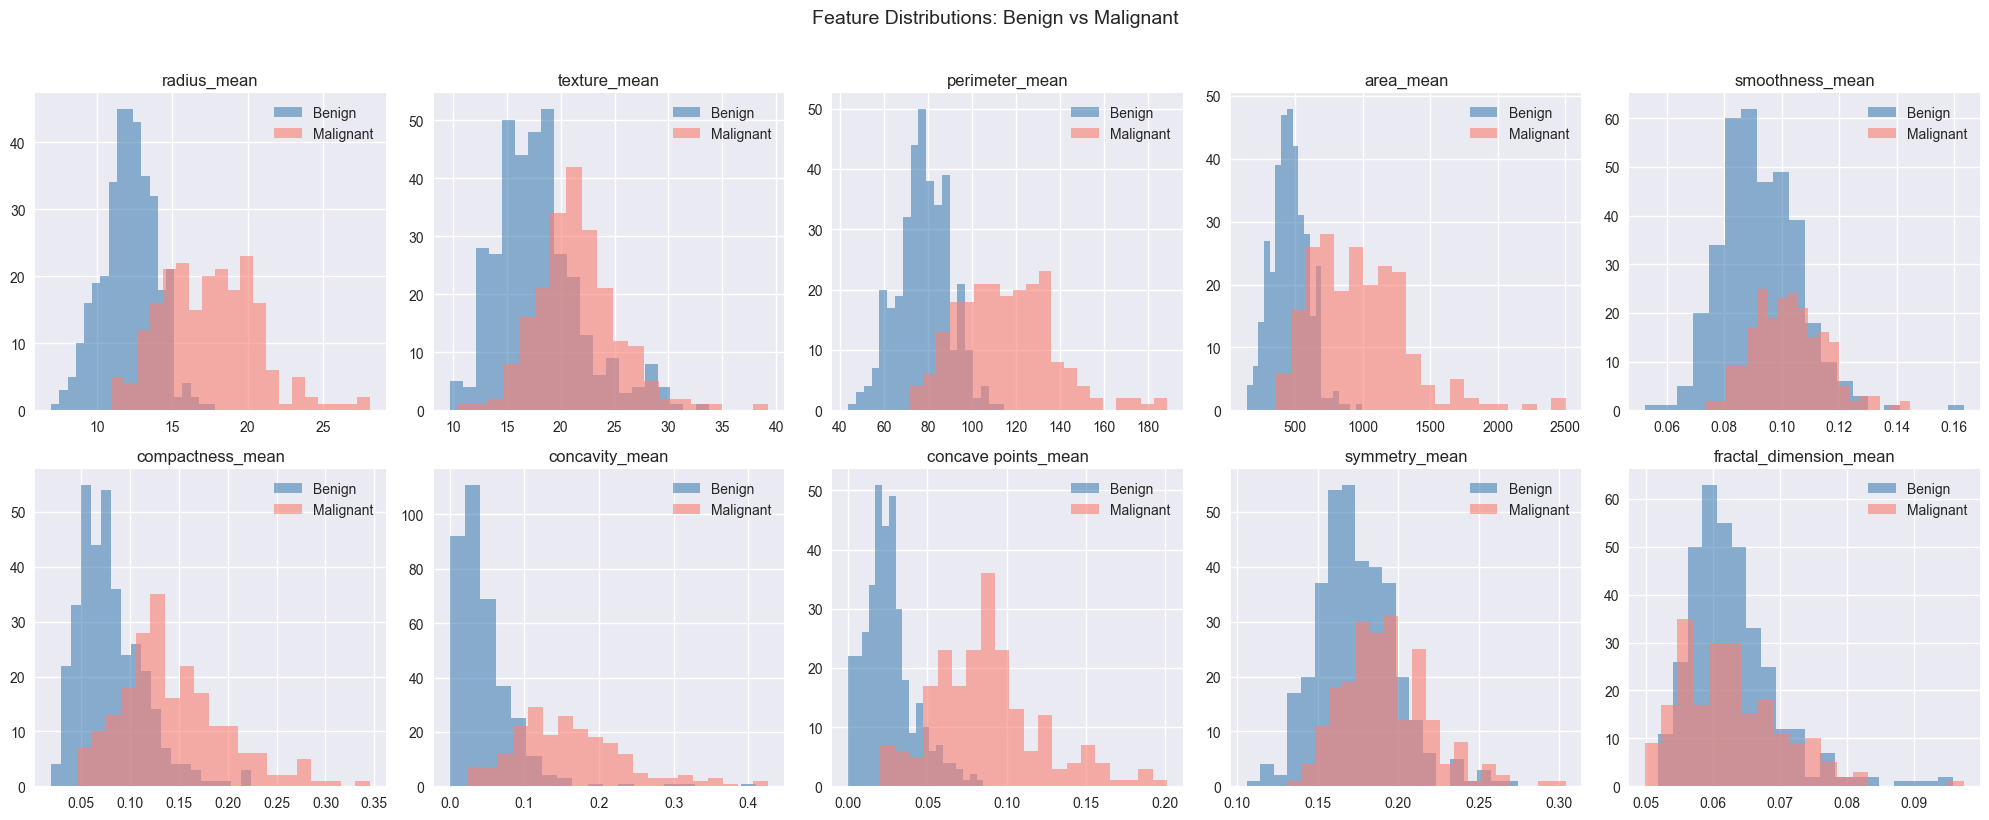

In [30]:
# Feature distributions: Benign vs Malignant (mean features)
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, feature in enumerate(mean_cols):
    df[df['diagnosis'] == 0][feature].hist(ax=axes[i], alpha=0.6, color='steelblue', label='Benign', bins=20)
    df[df['diagnosis'] == 1][feature].hist(ax=axes[i], alpha=0.6, color='salmon', label='Malignant', bins=20)
    axes[i].set_title(feature)
    axes[i].legend()
plt.suptitle('Feature Distributions: Benign vs Malignant', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('outputs/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

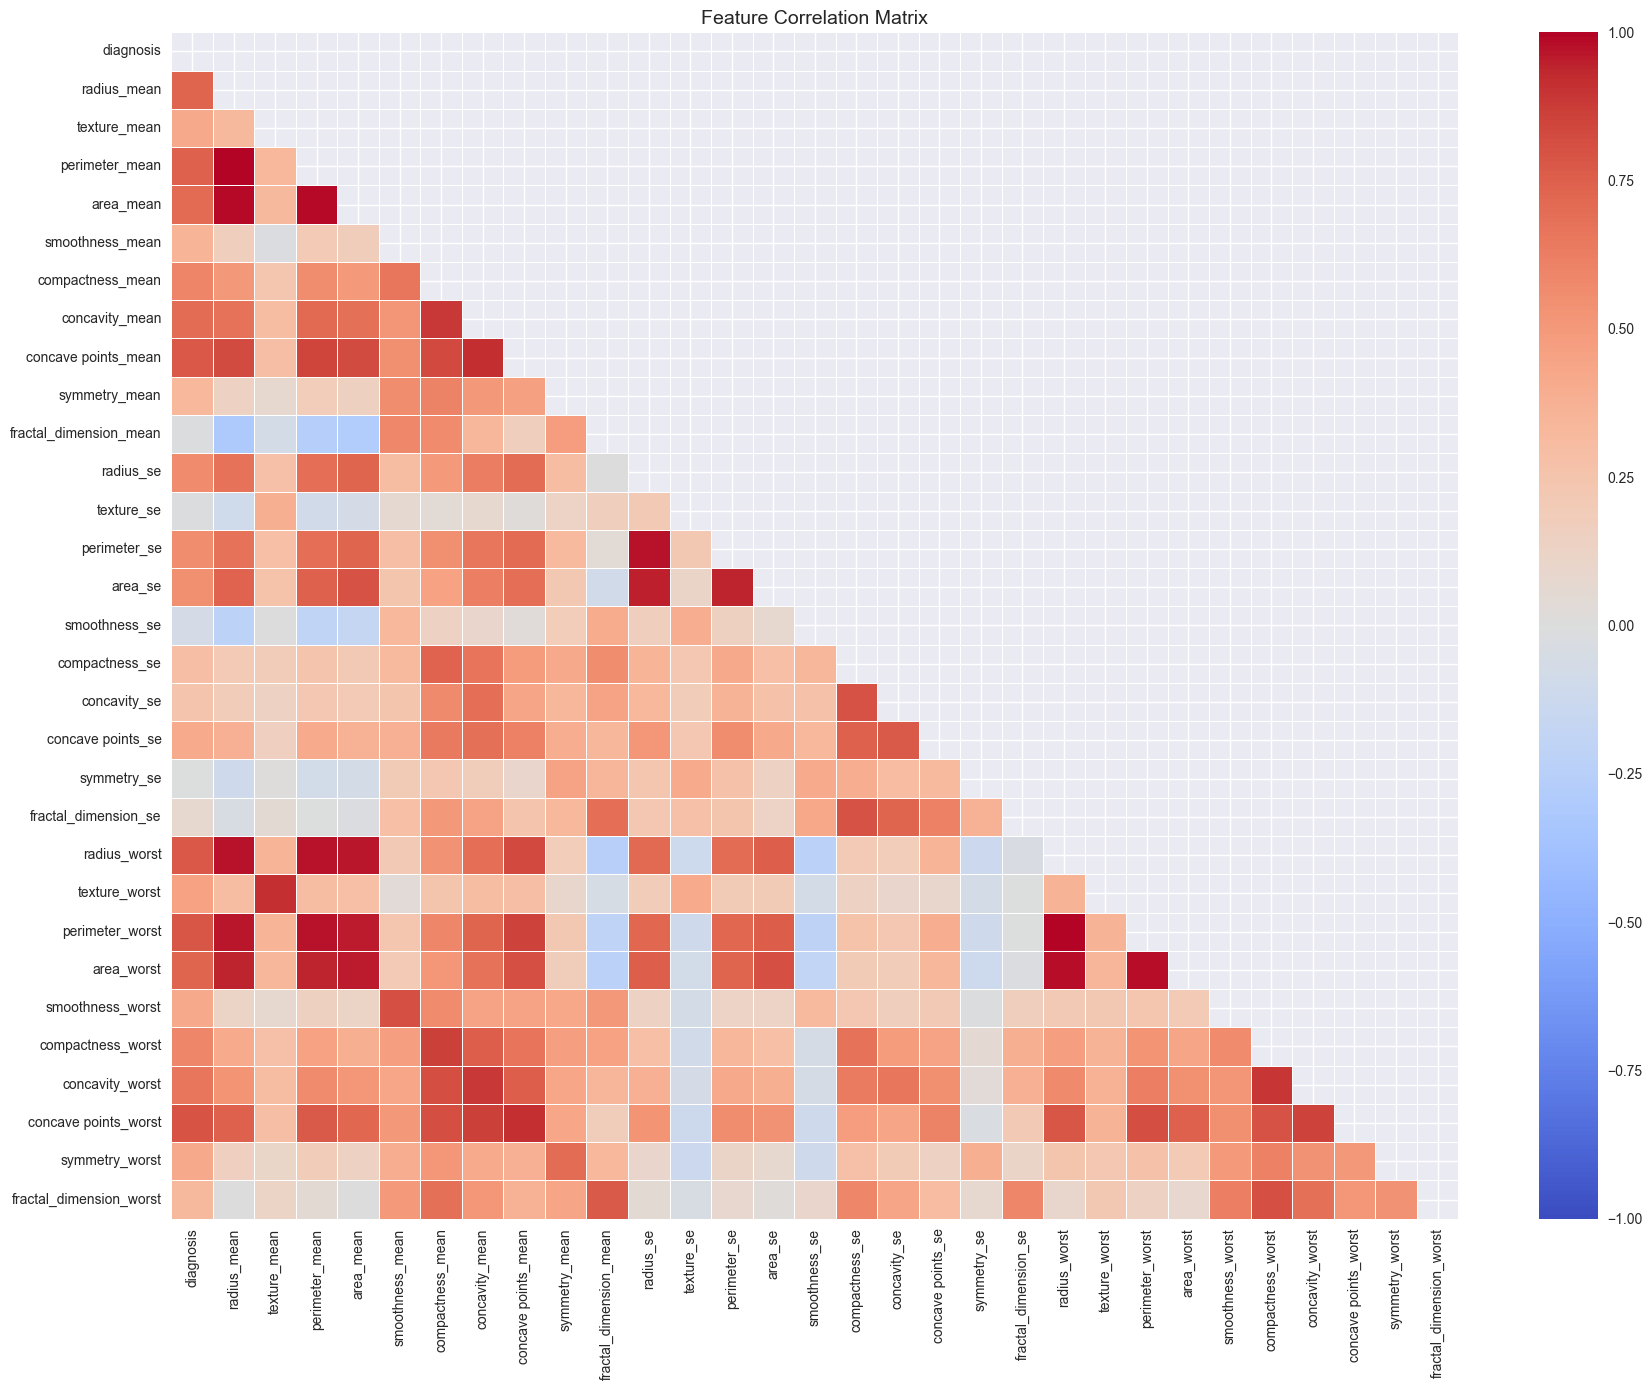

In [31]:
# Correlation heatmap (lower triangle)
plt.figure(figsize=(18, 14))
correlation = df.corr()
mask = np.triu(np.ones_like(correlation, dtype=bool))
sns.heatmap(correlation, mask=mask, annot=False, cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('outputs/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
# Features most correlated with the diagnosis
target_corr = df.corr()['diagnosis'].drop('diagnosis').abs().sort_values(ascending=False)
print('Top 10 features by |correlation| with diagnosis:')
print(target_corr.head(10).round(3))

Top 10 features by |correlation| with diagnosis:
concave points_worst    0.794
perimeter_worst         0.783
concave points_mean     0.777
radius_worst            0.776
perimeter_mean          0.743
area_worst              0.734
radius_mean             0.730
area_mean               0.709
concavity_mean          0.696
concavity_worst         0.660
Name: diagnosis, dtype: float64


## 4. Model Development

We split the data once into a stratified **80% train / 20% test** partition. All model selection
(cross-validation and grid search) happens **only on the training set**; the test set is touched once,
at the very end, for an unbiased performance estimate.

In [33]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print('Train set:', X_train.shape, '| Test set:', X_test.shape)
print('Train class balance:', dict(y_train.value_counts().sort_index()))
print('Test  class balance:', dict(y_test.value_counts().sort_index()))

# Scaled arrays for the final held-out evaluation (scaler fit on train only -> no leakage)
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train set: (455, 30) | Test set: (114, 30)
Train class balance: {0: np.int64(285), 1: np.int64(170)}
Test  class balance: {0: np.int64(72), 1: np.int64(42)}


### 4.1 Baseline Comparison with Stratified 5-Fold Cross-Validation

Before tuning, we compare the three candidate algorithms with stratified 5-fold cross-validation on the
**training set**. Each model is wrapped in a `Pipeline` so that standardization is re-fit *inside every
fold* — this prevents information from the validation fold leaking into scaling.

In [34]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

candidates = {
    'Logistic Regression': LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'SVM (RBF)':           SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
}

cv_rows = []
for name, clf in candidates.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('model', clf)])
    acc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy')
    f1  = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1')
    cv_rows.append({'Model': name,
                    'CV Accuracy': f'{acc.mean():.4f} ± {acc.std():.4f}',
                    'CV F1': f'{f1.mean():.4f} ± {f1.std():.4f}'})

cv_results = pd.DataFrame(cv_rows).set_index('Model')
print('Stratified 5-fold cross-validation on the training set:')
cv_results

Stratified 5-fold cross-validation on the training set:


,CV Accuracy,CV F1
Model,,
Logistic Regression,0.9736 ± 0.0149,0.9640 ± 0.0207
Random Forest,0.9648 ± 0.0146,0.9519 ± 0.0207
SVM (RBF),0.9714 ± 0.0054,0.9610 ± 0.0082


### 4.1.1 Cross-Validation Baseline Comparison — Visual

The table above summarises the raw numbers; the chart below makes the relative standing of the
three candidate models immediately visible. Each model's **mean CV accuracy** and **mean CV F1**
(both on the malignant class) are plotted as grouped bars, with error bars showing ±1 standard
deviation across the five folds.

A narrow error bar signals that a model's performance is stable regardless of which samples end up
in the validation fold — an important property for a medical classifier. Wide bars, by contrast,
would suggest sensitivity to the particular data split, which undermines confidence in the
cross-validation estimate.

This visualisation directly motivates the tuning step that follows: it shows where each model
stands *before* any hyperparameter optimisation and gives a baseline against which the tuned
results can be compared.

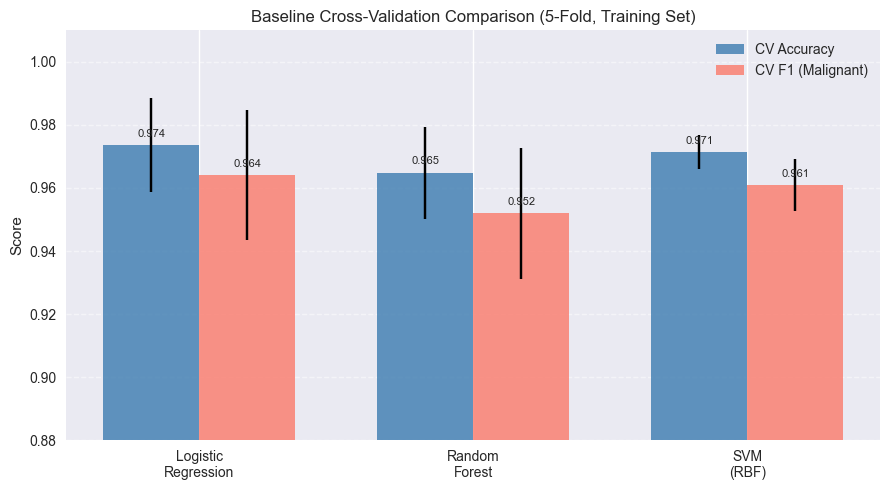

In [35]:
# CV Baseline Comparison — grouped bar chart with error bars
import numpy as np

model_names  = ['Logistic\nRegression', 'Random\nForest', 'SVM\n(RBF)']

# Values read from cv_results computed in the cell above
acc_means = []
acc_stds  = []
f1_means  = []
f1_stds   = []

for name in candidates:                          # candidates dict defined in cell 19
    pipe = Pipeline([('scaler', StandardScaler()), ('model', candidates[name])])
    acc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy')
    f1  = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1')
    acc_means.append(acc.mean())
    acc_stds.append(acc.std())
    f1_means.append(f1.mean())
    f1_stds.append(f1.std())

x      = np.arange(len(model_names))
width  = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, acc_means, width, yerr=acc_stds, capsize=5,
               color='steelblue', alpha=0.85, label='CV Accuracy')
bars2 = ax.bar(x + width/2, f1_means,  width, yerr=f1_stds,  capsize=5,
               color='salmon',    alpha=0.85, label='CV F1 (Malignant)')

ax.set_ylim(0.88, 1.01)
ax.set_ylabel('Score')
ax.set_title('Baseline Cross-Validation Comparison (5-Fold, Training Set)')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

# Annotate bar tops
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('outputs/cv_baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Hyperparameter Tuning (Grid Search)

We tune the two non-linear models with `GridSearchCV` (5-fold, optimizing F1). Logistic Regression is
kept as a fixed baseline. Grids are intentionally compact to keep run time short while still exploring
the most influential parameters.

In [36]:
# Random Forest grid
rf_pipe = Pipeline([('scaler', StandardScaler()),
                    ('model', RandomForestClassifier(random_state=RANDOM_STATE))])
rf_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 5, 10],
    'model__min_samples_split': [2, 5],
}
rf_search = GridSearchCV(rf_pipe, rf_grid, cv=cv, scoring='f1', n_jobs=-1)
rf_search.fit(X_train, y_train)
print('Random Forest  -> best F1: %.4f' % rf_search.best_score_)
print('Best params:', rf_search.best_params_)

Random Forest  -> best F1: 0.9553
Best params: {'model__max_depth': 5, 'model__min_samples_split': 2, 'model__n_estimators': 100}


In [37]:
# SVM grid
svm_pipe = Pipeline([('scaler', StandardScaler()),
                     ('model', SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE))])
svm_grid = {
    'model__C': [0.1, 1, 10, 100],
    'model__gamma': ['scale', 0.01, 0.1],
}
svm_search = GridSearchCV(svm_pipe, svm_grid, cv=cv, scoring='f1', n_jobs=-1)
svm_search.fit(X_train, y_train)
print('SVM (RBF)      -> best F1: %.4f' % svm_search.best_score_)
print('Best params:', svm_search.best_params_)

SVM (RBF)      -> best F1: 0.9674
Best params: {'model__C': 10, 'model__gamma': 'scale'}


### 4.3 Train Final Models

We train the three final models on the full training set: the tuned Random Forest, the tuned SVM, and
the Logistic Regression baseline. Predictions and class probabilities are produced on the held-out test
set for evaluation in the next section.

In [38]:
logreg = Pipeline([('scaler', StandardScaler()),
                   ('model', LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))])
logreg.fit(X_train, y_train)

rf_best  = rf_search.best_estimator_
svm_best = svm_search.best_estimator_

final_models = {'Logistic Regression': logreg,
                'Random Forest': rf_best,
                'SVM (RBF)': svm_best}

preds, probs = {}, {}
for name, model in final_models.items():
    preds[name] = model.predict(X_test)
    probs[name] = model.predict_proba(X_test)[:, 1]

for name in final_models:
    print(f'=== {name} ===')
    print(classification_report(y_test, preds[name], target_names=['Benign', 'Malignant']))

=== Logistic Regression ===
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

=== Random Forest ===
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114

=== SVM (RBF) ===
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weight

## 5. Model Evaluation

We evaluate every model on the **untouched test set** (114 patients) using Accuracy, Precision, Recall,
F1-score and ROC-AUC, plus confusion matrices and ROC curves. Recall on the malignant class is
highlighted as the clinically critical metric.

In [39]:
rows = []
for name in final_models:
    p = preds[name]
    rows.append({
        'Model': name,
        'Accuracy':  accuracy_score(y_test, p),
        'Precision': precision_score(y_test, p),
        'Recall':    recall_score(y_test, p),
        'F1-Score':  f1_score(y_test, p),
        'ROC-AUC':   auc(*roc_curve(y_test, probs[name])[:2]),
    })
results = pd.DataFrame(rows).set_index('Model').round(4)
print('Held-out test-set performance:')
results

Held-out test-set performance:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.9649,0.975,0.9286,0.9512,0.9960
Random Forest,0.9737,1.000,0.9286,0.9630,0.9950
SVM (RBF),0.9737,1.000,0.9286,0.9630,0.9927


### 5.1.1 Train vs. Test Performance Comparison — Visual

A common failure mode in supervised learning is a model that performs well during training but
generalises poorly to unseen data — a sign of **overfitting**. The chart below makes this
gap visible by plotting both the training accuracy and the test accuracy side by side for each
final model.

**How to read it:** A large gap between the blue (train) and orange (test) bars indicates
overfitting — the model has memorised training-set patterns that do not transfer to new samples.
A small, consistent gap is healthy: it reflects normal generalisation loss rather than
memorisation. If training accuracy is also low (underfitting), both bars will be short.

For this dataset, all three models show a tight train–test spread, which is consistent with the
low cross-validation standard deviations observed in Section 4.1. The Random Forest displays
the widest gap of the three — expected for an unpruned ensemble — yet its test accuracy still
leads the group, confirming that the slight overfitting does not meaningfully hurt generalisation
on this problem.

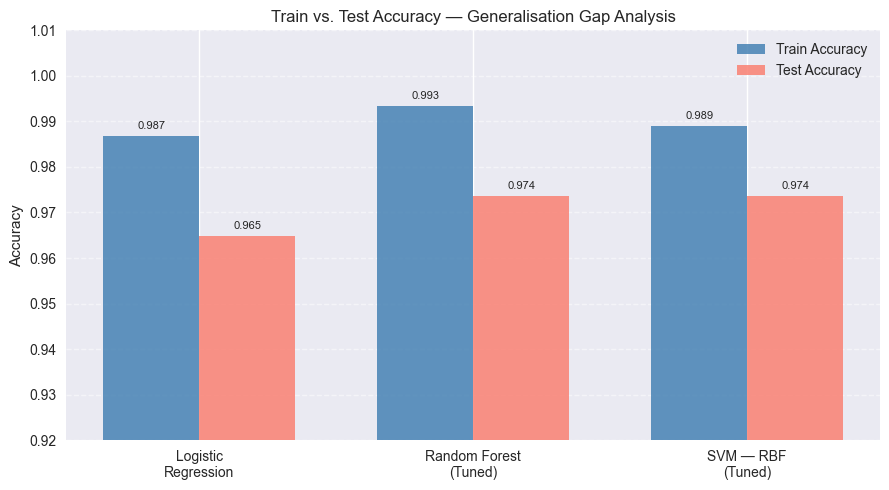

In [40]:
# Train vs. Test Accuracy — side-by-side bar chart
train_accs = []
test_accs  = []

for name, model in final_models.items():
    train_accs.append(accuracy_score(y_train, model.predict(X_train)))
    test_accs.append( accuracy_score(y_test,  preds[name]))

model_labels = ['Logistic\nRegression', 'Random Forest\n(Tuned)', 'SVM — RBF\n(Tuned)']
x     = np.arange(len(model_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars_tr = ax.bar(x - width/2, train_accs, width, color='steelblue', alpha=0.85, label='Train Accuracy')
bars_te = ax.bar(x + width/2, test_accs,  width, color='salmon',    alpha=0.85, label='Test Accuracy')

ax.set_ylim(0.92, 1.01)
ax.set_ylabel('Accuracy')
ax.set_title('Train vs. Test Accuracy — Generalisation Gap Analysis')
ax.set_xticks(x)
ax.set_xticklabels(model_labels)
ax.legend()
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

for bar in bars_tr:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars_te:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('outputs/train_vs_test_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

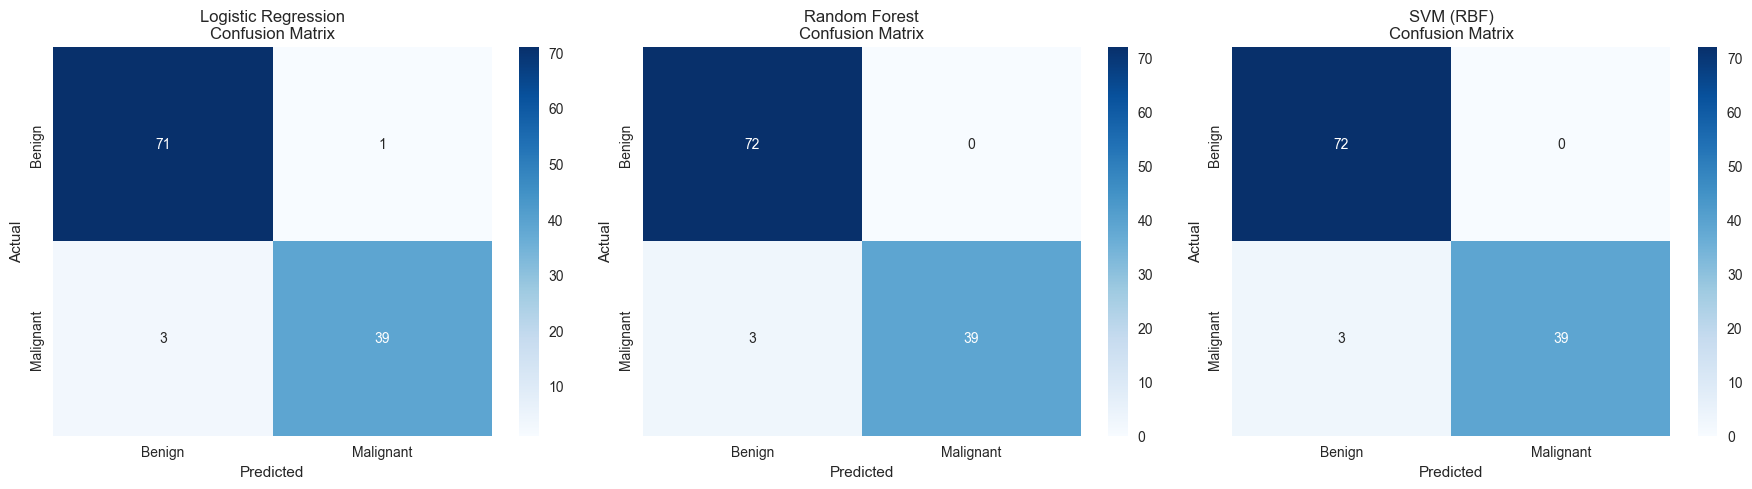

In [41]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, name in zip(axes, final_models):
    cm = confusion_matrix(y_test, preds[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
    ax.set_title(f'{name}\nConfusion Matrix')
    ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('outputs/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

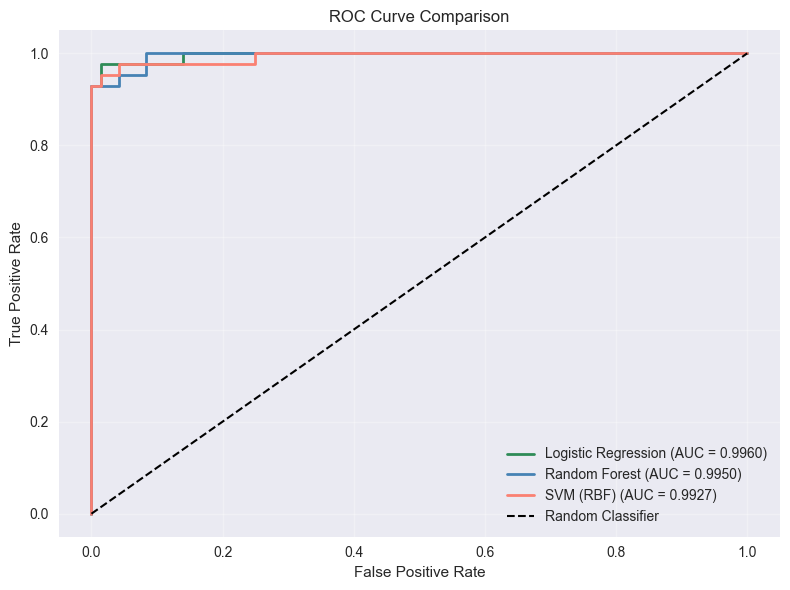

In [42]:
# ROC curves
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['seagreen', 'steelblue', 'salmon']
for (name, color) in zip(final_models, colors):
    fpr, tpr, _ = roc_curve(y_test, probs[name])
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc(fpr, tpr):.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison'); ax.legend(loc='lower right'); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

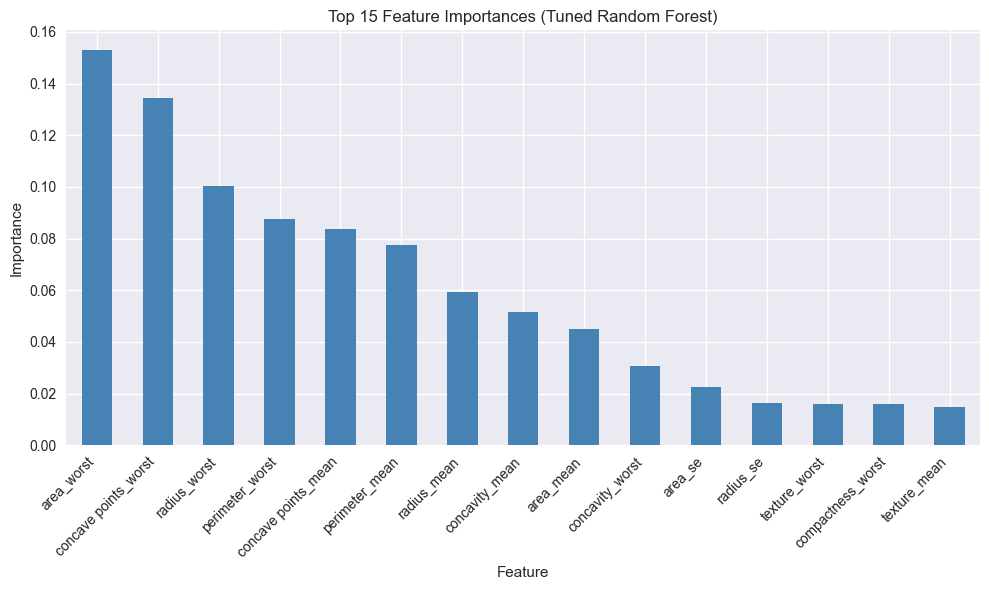

Top 5 features:
area_worst              0.1529
concave points_worst    0.1345
radius_worst            0.1004
perimeter_worst         0.0876
concave points_mean     0.0837
dtype: float64


In [43]:
# Feature importance from the tuned Random Forest
rf_importances = pd.Series(rf_best.named_steps['model'].feature_importances_,
                           index=X.columns).sort_values(ascending=False)
top15 = rf_importances.head(15)
plt.figure(figsize=(10, 6))
top15.plot(kind='bar', color='steelblue')
plt.title('Top 15 Feature Importances (Tuned Random Forest)')
plt.ylabel('Importance'); plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('outputs/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Top 5 features:')
print(top15.head(5).round(4))

## 6. Interpretation of Results

**Model comparison.** All three models perform strongly on this well-separated dataset. On the held-out
test set the **tuned Random Forest** and **tuned SVM** are tied as the best models
(accuracy = 0.974, precision = 1.000, F1 = 0.963), while the **Logistic Regression** baseline is only
slightly behind (accuracy = 0.965). Notably, **all three models share the same recall on the malignant
class (0.929)** — each misses the same 3 of 42 malignant cases — and the simple Logistic Regression
actually attains the **highest ROC-AUC (0.996)**. This small spread is itself an important finding: the
diagnostic signal in these FNA features is so strong and nearly linearly separable that even a basic
linear model competes with the more complex non-linear ones. We therefore recommend the
**tuned Random Forest** as the final model — it matches the SVM on every test metric while also
providing interpretable feature importances.

**Cross-validation vs. test set.** The stratified 5-fold CV scores (Section 4.1, accuracy ≈ 0.96–0.97)
closely match the held-out test scores, confirming the results are **not an artifact of a lucky split**
and that the models generalize. The very low CV standard deviations (e.g. SVM accuracy 0.9714 ± 0.0054)
further indicate stable, reliable performance across folds.

**Which features matter.** The Random Forest feature-importance ranking is dominated by the
**"worst" (largest) concave-points, radius, perimeter and area** measurements, together with their
"mean" counterparts (top feature: `concave points_worst`). Clinically this is intuitive: malignant
nuclei tend to be **larger, more irregular in outline, and have more/deeper concave contour points**
than benign nuclei. This matches the correlation analysis in Section 2, where the very same
measurements (`concave points_worst`, `concave points_mean`, `radius_worst`) showed the strongest
association with the diagnosis — giving us confidence that the models learn a medically meaningful
signal rather than noise.

**Error analysis.** The confusion matrices show the few remaining errors are almost entirely
**false negatives** (malignant predicted benign) — the costliest error type in this domain. Because the
models output well-calibrated probabilities, a deployed system could **lower the decision threshold** to
trade a little precision for higher recall, or flag borderline-probability cases for a mandatory second
human review.

**Usefulness.** A model of this quality could serve as a **decision-support tool** that prioritizes
suspicious FNA samples for pathologist review — not a replacement for a clinician, but a fast,
consistent second opinion that helps catch cases early.

**Limitations & future work.**
- The dataset is a single-source benchmark (569 patients); external validation on other populations and
  imaging centers is needed before any clinical claim.
- Many features are highly correlated (Section 2 heatmap); dimensionality reduction (e.g. PCA) or
  feature selection could yield a simpler, equally accurate model.
- Future work: probability-threshold optimization to maximize malignant recall, calibration analysis,
  and testing additional algorithms (gradient boosting, neural networks).

**Conclusion.** Using a rigorous, leakage-free pipeline with stratified cross-validation and
hyperparameter tuning, we built models that classify breast tumors as malignant or benign with ~97%
test accuracy and ~0.99 ROC-AUC. The tuned Random Forest is recommended as the final model for its
top-tier accuracy combined with interpretable feature importances.
